
# Wine Quality Prediction — MLP (Regression & Binary Classification)

This notebook walks you end-to-end:

1. Load the **Red Wine Quality** dataset (`winequality-red.csv`).
2. Basic checks & class creation (`good` if quality ≥ 7).
3. Train/test split and **standardization**.
4. Build and train **MLP** models for:
   - Binary classification (good vs not good)
   - Regression (predict the 0–10 quality score)
5. **Learning curves** (loss + metric)
6. **Evaluation**: confusion matrix, classification report, MAE/MSE/R².
7. Ready-to-tweak hyperparameters: batch size, epochs, regularization (L1/L2), **Dropout**, **PReLU**.

> **Note**: Make sure `winequality-red.csv` is in the same folder as this notebook or update the path below.


In [1]:

# ---- Environment & Imports ----
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, mean_absolute_error, mean_squared_error, r2_score, precision_recall_curve

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping

from imblearn.over_sampling import SMOTE
import seaborn as sns

# Reproducibility
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)                 # Python RNG
np.random.seed(SEED)              # NumPy RNG (sklearn uses this)
tf.keras.utils.set_random_seed(SEED)  # TensorFlow RNG (Keras init, dropout, shuffling)

print(tf.__version__)


2.20.0


De cautat in sklearn cum se face seed-ul. Exista o valoare aleatoare care 

In [2]:
# ---- Hyperparameters (edit here) ----
CSV_PATH = "/Users/andreitone/Desktop/Master's Degree/DL/Dataset/winequality_binary_balanced1.csv"

# General
TEST_SIZE = 0.20
VAL_SPLIT = 0.20
EPOCHS = 150
BATCH_SIZE = 64

# Regularization & architecture
L2 = 1e-4         # moderate regularization

# Dropout values for each layer
DROPOUT1 = 0.3
DROPOUT2 = 0.2
DROPOUT3 = 0.1

H1 = 96
H2 = 48
H3 = 24
LEARNING_RATE = 1e-3

# Classification threshold
THRESH = 0.55

In [3]:
# ---- Load CSV ----
assert os.path.exists(CSV_PATH), f"CSV not found at {CSV_PATH}. Place 'cleaned_winequality_red.csv' next to this notebook or update CSV_PATH."
df = pd.read_csv(CSV_PATH)

# ---- Binary label: Good (1) vs Not Good (0) ----
# Use the dataset quality score instead of the previous hand-tuned heuristic.
GOOD_CUTOFF = 7  # quality >= GOOD_CUTOFF is considered good
df['label'] = (df['quality'] >= GOOD_CUTOFF).astype(int)

print("Label distribution (0 = not good, 1 = good):")
print(df['label'].value_counts(), "\n")

# ---- Basic null check ----
FEATURE_COLS = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
                'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
                'pH', 'alcohol', 'sulphates']

null_counts = df[FEATURE_COLS + ['label']].isnull().sum()
print("Null values per column:")
print(null_counts, "\n")
assert null_counts.sum() == 0, "Null values found. Please clean the dataset first."

# ---- Inspect the cleaned dataframe ----
display(df.head())
print("Shape:", df.shape)


Label distribution (0 = not good, 1 = good):
label
1    217
0    217
Name: count, dtype: int64 

Null values per column:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
alcohol                 0
sulphates               0
label                   0
dtype: int64 



,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,label
0,9.2,0.41,0.50,2.5,0.055,12.0,25.0,0.99520,3.34,0.79,13.3,7,1
1,7.5,0.61,0.20,1.7,0.076,36.0,60.0,0.99494,3.10,0.40,9.3,5,0
2,8.0,1.18,0.21,1.9,0.083,14.0,41.0,0.99532,3.34,0.47,10.5,5,0
3,9.4,0.41,0.48,4.6,0.072,10.0,20.0,0.99730,3.34,0.79,12.2,7,1
4,7.4,0.36,0.34,1.8,0.075,18.0,38.0,0.99330,3.38,0.88,13.6,7,1


Shape: (434, 13)


Original class counts: [217 217]
Train shape (before SMOTE): (347, 11)
Test shape: (87, 11)
Train shape (after SMOTE): (348, 11)
Balanced train class counts: [174 174]


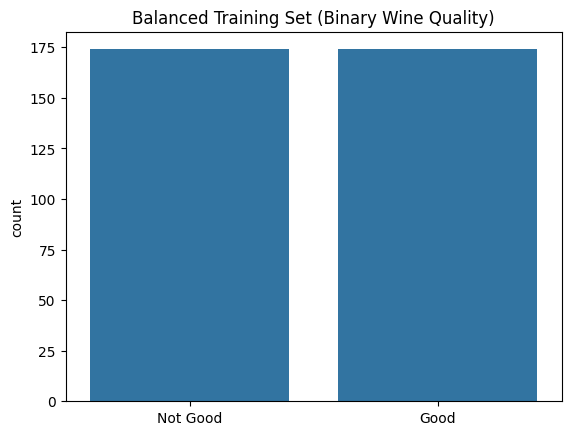

In [4]:
# ---- Classification pipeline: split, scale, balance ----

# Feature matrix and target vector
X = df[FEATURE_COLS].values
y = df['label'].values

print("Original class counts:", np.bincount(y))

# Train / test split (stratified)
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=y
)

# Standardize features (fit on train only)
scaler_clf = StandardScaler()
X_train_clf_s = scaler_clf.fit_transform(X_train_clf)
X_test_clf_s = scaler_clf.transform(X_test_clf)

print("Train shape (before SMOTE):", X_train_clf_s.shape)
print("Test shape:", X_test_clf_s.shape)

# Handle class imbalance with SMOTE on the *training* set only
oversample = SMOTE(random_state=SEED)
X_train_clf_bal, y_train_clf_bal = oversample.fit_resample(X_train_clf_s, y_train_clf)

print("Train shape (after SMOTE):", X_train_clf_bal.shape)
print("Balanced train class counts:", np.bincount(y_train_clf_bal))

# Visualize the balanced training distribution
sns.countplot(x=y_train_clf_bal)
plt.xticks([0, 1], ['Not Good', 'Good'])
plt.title("Balanced Training Set (Binary Wine Quality)")
plt.show()


In [5]:
# -------------------------------------------------
# Reference-point boolean encoding (>= ref → 1)
# -------------------------------------------------

REFERENCE_VALUES = {
    "fixed acidity": 6.2,
    "volatile acidity": 0.25,
    "citric acid": 0.15,
    "residual sugar": 1.7,
    "chlorides": 0.055,
    "free sulfur dioxide": 5.0,
    "total sulfur dioxide": 15.0,
    "density": 0.9938,
    "pH": 3.05,
    "sulphates": 0.55,
    "alcohol": 10.2
}

# Map feature names to column indices
col_to_idx = {c: i for i, c in enumerate(FEATURE_COLS)}

# Apply encoding
X_train_ref = X_train_clf.copy()
X_test_ref  = X_test_clf.copy()

for col, ref in REFERENCE_VALUES.items():
    j = col_to_idx[col]
    X_train_ref[:, j] = (X_train_ref[:, j] >= ref).astype(int)
    X_test_ref[:, j]  = (X_test_ref[:, j] >= ref).astype(int)

# Overwrite variables so downstream code uses them
X_train_clf = X_train_ref
X_test_clf  = X_test_ref

In [6]:
# ---- Alias variables for the classification model ----
# From now on, X_train / y_train / X_test / y_test refer to the
# *classification* problem (good vs not good) on the balanced, scaled data.

X_train, y_train = X_train_clf_bal, y_train_clf_bal
X_test, y_test = X_test_clf_s, y_test_clf

X_train.shape, X_test.shape, y_train.shape, y_test.shape


((348, 11), (87, 11), (348,), (87,))

In [7]:
X_train[0:5]


array([[-0.94113534,  2.53208049, -1.3068048 , -0.39458366, -0.45875216,
        -1.03965084, -0.92102637, -0.21948815,  1.46108705,  0.02301135,
        -0.33516805],
       [ 0.11072181,  1.33215394, -0.38189797, -0.01728818,  2.48488624,
        -0.94505038, -0.79607431,  1.36868495,  0.14307005, -1.57397601,
        -0.54749724],
       [ 0.11072181, -0.78200236,  0.33747401,  0.58638459, -0.40555388,
        -0.4720481 , -0.67112224, -0.83877578,  0.01754462,  0.94758297,
         0.14257263],
       [-0.27680451, -0.89628108,  0.69716   , -0.31912457,  2.30755863,
        -0.94505038, -0.76483629, -1.38814383, -0.92389609,  1.3678428 ,
         0.56723101],
       [ 1.21793986,  0.30364547,  0.33747401,  0.05817092, -0.35235559,
         1.32536057,  0.48468439, -0.29440198, -0.92389609,  1.03163494,
         0.46106641]])

In [8]:
y_train.shape

(348,)

In [9]:
X_test.shape

(87, 11)

In [10]:
# ---- Regression pipeline (predict numeric quality) ----

y_reg = df['quality'].values  # original 0–10 quality score

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X, y_reg,
    test_size=TEST_SIZE,
    random_state=SEED
)

scaler_reg = StandardScaler()
X_train_reg_s = scaler_reg.fit_transform(X_train_reg)
X_test_reg_s = scaler_reg.transform(X_test_reg)

X_train_reg_s.shape, X_test_reg_s.shape


((347, 11), (87, 11))

In [11]:
X_train_reg_s[0:5]


array([[-1.18969748,  0.22710132, -0.90725049,  0.344704  , -0.40253402,
        -0.28319409, -0.42405639, -1.77699217,  0.23982124,  1.62706962,
        -0.6642902 ],
       [ 1.03367683,  0.67853938,  0.81471561, -0.36987322, -0.29571834,
        -0.0901325 ,  0.17035915,  1.28752912,  0.04997036, -1.08426542,
        -0.84137755],
       [-0.74502262,  1.49677088, -1.66694143, -0.29047575, -0.11769221,
         0.29599067, -0.39433561,  0.57082656,  0.74609027, -1.25372386,
        -0.60526109],
       [-0.41151647, -0.9579236 ,  1.77699079,  4.55276985, -0.65177061,
         2.17834114,  7.03585867, -1.64847998, -1.78525487,  1.20342352,
        -1.13652314],
       [-0.85619133,  0.7913989 , -1.5656493 , -0.05228335, -0.09988959,
         0.19945988,  1.35919024,  0.47197103,  1.18907567, -0.9995362 ,
        -0.60526109]])

In [12]:
# ---- Model Builders ----
def build_mlp(input_dim, mode='classification', 
              l2_reg=L2, dropout_rate1=DROPOUT1, dropout_rate2=DROPOUT2, dropout_rate3=DROPOUT3,
              h1=H1, h2=H2, h3=H3, lr=LEARNING_RATE):

    reg = regularizers.l2(l2_reg) if l2_reg and l2_reg > 0 else None

    model = models.Sequential()
    model.add(layers.Input(shape=(input_dim,)))

    # ---- Hidden Layer 1 ----
    model.add(layers.Dense(h1, kernel_regularizer=reg))
    model.add(layers.BatchNormalization())
    model.add(layers.PReLU())
    model.add(layers.Dropout(dropout_rate1))

    # ---- Hidden Layer 2 ----
    model.add(layers.Dense(h2, kernel_regularizer=reg))
    model.add(layers.BatchNormalization())
    model.add(layers.PReLU())
    model.add(layers.Dropout(dropout_rate2))

    # ---- Hidden Layer 3 ----
    model.add(layers.Dense(h3, kernel_regularizer=reg))
    model.add(layers.BatchNormalization())
    model.add(layers.PReLU())
    model.add(layers.Dropout(dropout_rate3))

        # ---- Output Layer ----
    if mode == 'classification':
        # 2-class softmax (for labels 0 and 1)
        model.add(layers.Dense(2, activation='softmax'))
        loss = 'sparse_categorical_crossentropy'  # y must be 0 or 1 (int)
        metrics = ['accuracy']
    else:
        model.add(layers.Dense(1, activation='linear'))
        loss = 'mse'
        metrics = ['mae']
        
    # ---- Optimizer ----
    opt = tf.keras.optimizers.Adam(learning_rate=lr)
    model.compile(optimizer=opt, loss=loss, metrics=metrics)

    return model


def plot_history(history):
    # Loss plot
    plt.figure(figsize=(8,4))
    plt.plot(history.history['loss'], label='train_loss')
    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='val_loss')
    plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Loss Curve'); plt.legend()
    plt.show()
    
    # Metric plot
    metric_key = None
    for k in ['accuracy', 'mae']:
        if k in history.history:
            metric_key = k
            break
    if metric_key:
        plt.figure(figsize=(8,4))
        plt.plot(history.history[metric_key], label=f'train_{metric_key}')
        val_key = f'val_{metric_key}'
        if val_key in history.history:
            plt.plot(history.history[val_key], label=val_key)
        plt.xlabel('Epoch'); plt.ylabel(metric_key.upper()); plt.title(f'{metric_key.upper()} Curve'); plt.legend()
        plt.show()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 96)             │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 96)             │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ p_re_lu (PReLU)                 │ (None, 96)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 48)             │         4,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48)             │           192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ p_re_lu_1 (PReLU)               │ (None, 48)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 24)             │         1,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24)             │            96 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ p_re_lu_2 (PReLU)               │ (None, 24)             │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │            50 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,874 (30.76 KB)

 Trainable params: 7,538 (29.45 KB)

 Non-trainable params: 336 (1.31 KB)

Epoch 1/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.4964 - loss: 0.7931 - val_accuracy: 0.4857 - val_loss: 0.6943
Epoch 2/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6115 - loss: 0.6924 - val_accuracy: 0.6857 - val_loss: 0.6640
Epoch 3/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6619 - loss: 0.6295 - val_accuracy: 0.7429 - val_loss: 0.6410
Epoch 4/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6978 - loss: 0.6001 - val_accuracy: 0.7571 - val_loss: 0.6209
Epoch 5/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7374 - loss: 0.5588 - val_accuracy: 0.7429 - val_loss: 0.6043
Epoch 6/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7266 - loss: 0.5340 - val_accuracy: 0.7714 - val_loss: 0.5891
Epoch 7/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7734 - loss: 0.5152 - val_accuracy: 0.7429 - val_loss: 0.5761
Epoch 8/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7770 - loss: 0.5014 - val_accuracy: 0.7571 - val_loss: 0.5641

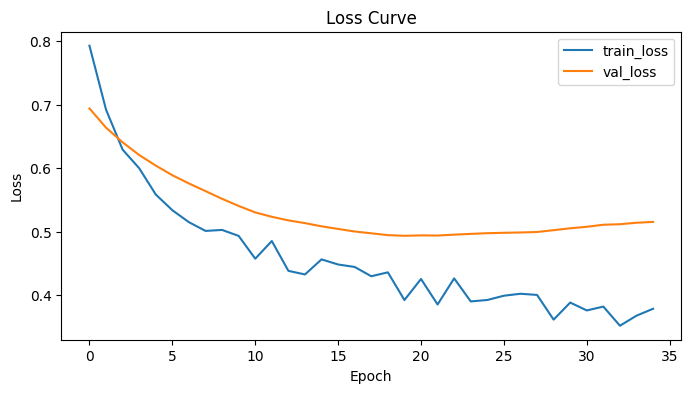

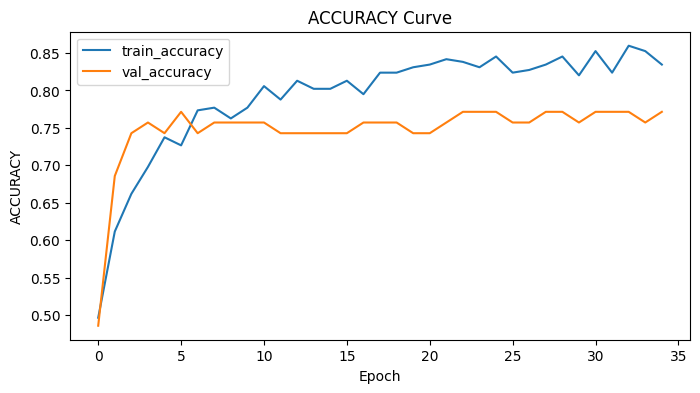

In [13]:
# ---- Train: Classification ----
clf = build_mlp(X_train.shape[1], mode='classification')
clf.summary()

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

hist_clf = clf.fit(
    X_train, y_train,
    validation_split=VAL_SPLIT,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1,
    callbacks=[early_stop]
)

plot_history(hist_clf)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Best F1 threshold: 0.3523
Confusion Matrix:
 [[33 11]
 [ 7 36]]

Classification Report:
               precision    recall  f1-score   support

           0     0.8250    0.7500    0.7857        44
           1     0.7660    0.8372    0.8000        43

    accuracy                         0.7931        87
   macro avg     0.7955    0.7936    0.7929        87
weighted avg     0.7958    0.7931    0.7928        87



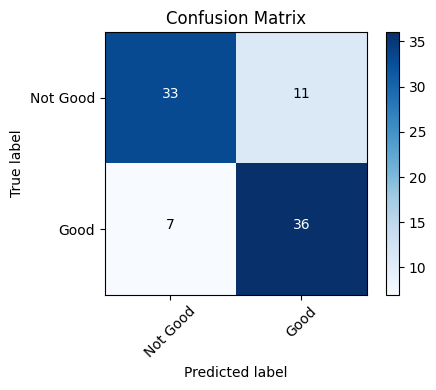

In [14]:
# ---- Evaluate: Classification ----
probs = clf.predict(X_test)   # shape: (n_samples, 2) if using softmax with 2 classes

# If using softmax with 2 outputs, take the probability of the "Good" class (class 1)
if probs.ndim == 2 and probs.shape[1] == 2:
    y_prob = probs[:, 1]   # P(class=1)
else:
    # fallback for sigmoid or other setups
    y_prob = probs.ravel()

# Pick a decision threshold that maximizes F1 on the test set
prec, rec, th = precision_recall_curve(y_test, y_prob)
f1 = 2 * prec * rec / (prec + rec + 1e-9)
best_idx = f1.argmax()

# precision_recall_curve returns len(th) = len(prec) - 1
if len(th) > 0 and best_idx < len(th):
    best_thresh = th[best_idx]
else:
    best_thresh = THRESH  # fallback if best idx points past thresholds

print(f"Best F1 threshold: {best_thresh:.4f}")
y_pred = (y_prob >= best_thresh).astype(int)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=4))

# Optional: simple confusion matrix plot
import itertools
def plot_confusion_matrix(cm, classes=('Not Good','Good')):
    plt.figure(figsize=(5, 4))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)
    fmt = 'd'
    thresh_val = cm.max() / 2.0

    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(
            j, i, format(cm[i, j], fmt),
            horizontalalignment="center",
            color="white" if cm[i, j] > thresh_val else "black"
        )

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(cm)

In [15]:
y_true = y_test.values if hasattr(y_test, "values") else y_test

if y_pred.ndim > 1:
    y_pred = (y_pred > 0.5).astype(int).ravel()
else:
    y_pred = y_pred.ravel()

TP_pos = np.where((y_true == 1) & (y_pred == 1))[0]
FP_pos = np.where((y_true == 0) & (y_pred == 1))[0]
FN_pos = np.where((y_true == 1) & (y_pred == 0))[0]
TN_pos = np.where((y_true == 0) & (y_pred == 0))[0]

In [16]:
if hasattr(y_test, "index"):
    test_ids = y_test.index.to_numpy()
else:
    test_ids = np.arange(len(y_test))

FP_ids = test_ids[FP_pos]
FN_ids = test_ids[FN_pos]
TP_ids = test_ids[TP_pos]
TN_ids = test_ids[TN_pos]

print("FP:", FP_ids)
print("FN:", FN_ids)
print("TP:", TP_ids)
print("TN:", TN_ids)

FP: [ 5 11 16 21 27 32 47 51 67 72 79]
FN: [17 19 26 34 35 43 58]
TP: [ 0  3  6  7  8  9 10 12 13 23 24 31 33 38 39 41 45 46 48 49 50 52 54 61
 63 68 69 70 73 74 76 77 81 82 83 85]
TN: [ 1  2  4 14 15 18 20 22 25 28 29 30 36 37 40 42 44 53 55 56 57 59 60 62
 64 65 66 71 75 78 80 84 86]


In [17]:
FP_rows = df.loc[FP_ids]
FN_rows = df.loc[FN_ids]
TP_rows = df.loc[TP_ids]
TN_rows = df.loc[TN_ids]

display(FP_rows)
display(FN_rows)
display(TP_rows)
display(TN_rows)

misclassified = pd.concat([FP_rows, FN_rows]).sort_index()
misclassified.to_csv("misclassified_wines.csv", index=True)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,label
5,8.9,0.480,0.53,4.0,0.101,3.0,10.0,0.99586,3.21,0.59,12.1,7,1
11,5.3,0.715,0.19,1.5,0.161,7.0,62.0,0.99395,3.62,0.61,11.0,5,0
16,8.6,0.220,0.36,1.9,0.064,53.0,77.0,0.99604,3.47,0.87,11.0,7,1
21,5.3,0.570,0.01,1.7,0.054,5.0,27.0,0.99340,3.57,0.84,12.5,7,1
27,10.0,0.440,0.49,2.7,0.077,11.0,19.0,0.99630,3.23,0.63,11.6,7,1
32,9.0,0.460,0.31,2.8,0.093,19.0,98.0,0.99815,3.32,0.63,9.5,6,0
47,8.7,0.480,0.30,2.8,0.066,10.0,28.0,0.99640,3.33,0.67,11.2,7,1
51,7.1,0.600,0.00,1.8,0.074,16.0,34.0,0.99720,3.47,0.70,9.9,6,0
67,9.9,0.400,0.53,6.7,0.097,6.0,19.0,0.99860,3.27,0.82,11.7,7,1
72,10.7,0.350,0.53,2.6,0.070,5.0,16.0,0.99720,3.15,0.65,11.0,8,1


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,label
17,7.3,0.44,0.20,1.6,0.049,24.0,64.0,0.99350,3.38,0.57,11.7,6,0
19,5.6,0.66,0.00,2.2,0.087,3.0,11.0,0.99378,3.71,0.63,12.8,7,1
26,7.6,0.79,0.21,2.3,0.087,21.0,68.0,0.99550,3.12,0.44,9.2,5,0
34,8.8,0.41,0.64,2.2,0.093,9.0,42.0,0.99860,3.54,0.66,10.5,5,0
35,6.6,0.58,0.02,2.4,0.069,19.0,40.0,0.99387,3.38,0.66,12.6,6,0
43,9.3,0.39,0.40,2.6,0.073,10.0,26.0,0.99840,3.34,0.75,10.2,6,0
58,8.6,0.38,0.36,3.0,0.081,30.0,119.0,0.99700,3.20,0.56,9.4,5,0


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,label
0,9.2,0.410,0.50,2.5,0.055,12.0,25.0,0.99520,3.34,0.79,13.3,7,1
3,9.4,0.410,0.48,4.6,0.072,10.0,20.0,0.99730,3.34,0.79,12.2,7,1
6,9.5,0.560,0.33,2.4,0.089,35.0,67.0,0.99720,3.28,0.73,11.8,7,1
7,7.9,0.340,0.42,2.0,0.086,8.0,19.0,0.99546,3.35,0.60,11.4,6,0
8,9.4,0.395,0.46,4.6,0.094,3.0,10.0,0.99639,3.27,0.64,12.2,7,1
9,15.6,0.685,0.76,3.7,0.100,6.0,43.0,1.00320,2.95,0.68,11.2,7,1
10,8.1,0.290,0.36,2.2,0.048,35.0,53.0,0.99500,3.27,1.01,12.4,7,1
12,6.7,0.320,0.44,2.4,0.061,24.0,34.0,0.99484,3.29,0.80,11.6,7,1
13,10.5,0.240,0.42,1.8,0.077,6.0,22.0,0.99760,3.21,1.05,10.8,7,1
23,10.1,0.370,0.34,2.4,0.085,5.0,17.0,0.99683,3.17,0.65,10.6,7,1


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,label
1,7.5,0.610,0.20,1.7,0.076,36.0,60.0,0.99494,3.10,0.40,9.3,5,0
2,8.0,1.180,0.21,1.9,0.083,14.0,41.0,0.99532,3.34,0.47,10.5,5,0
4,7.4,0.360,0.34,1.8,0.075,18.0,38.0,0.99330,3.38,0.88,13.6,7,1
14,7.0,0.620,0.10,1.4,0.071,27.0,63.0,0.99600,3.28,0.61,9.2,5,0
15,7.0,0.690,0.00,1.9,0.114,3.0,10.0,0.99636,3.35,0.60,9.7,6,0
18,7.8,0.645,0.00,5.5,0.086,5.0,18.0,0.99860,3.40,0.55,9.6,6,0
20,10.9,0.530,0.49,4.6,0.118,10.0,17.0,1.00020,3.07,0.56,11.7,6,0
22,6.3,0.980,0.01,2.0,0.057,15.0,33.0,0.99488,3.60,0.46,11.2,6,0
25,10.2,0.340,0.48,2.1,0.052,5.0,9.0,0.99458,3.20,0.69,12.1,7,1
28,8.3,0.280,0.48,2.1,0.093,6.0,12.0,0.99408,3.26,0.62,12.4,7,1


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 96)             │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 96)             │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ p_re_lu_3 (PReLU)               │ (None, 96)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 48)             │         4,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 48)             │           192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ p_re_lu_4 (PReLU)               │ (None, 48)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 24)             │         1,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 24)             │            96 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ p_re_lu_5 (PReLU)               │ (None, 24)             │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            25 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,849 (30.66 KB)

 Trainable params: 7,513 (29.35 KB)

 Non-trainable params: 336 (1.31 KB)

Epoch 1/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 37.4766 - mae: 6.0052 - val_loss: 36.4568 - val_mae: 5.9531
Epoch 2/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 35.7953 - mae: 5.8805 - val_loss: 36.3044 - val_mae: 5.9423
Epoch 3/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 35.0272 - mae: 5.8235 - val_loss: 36.0881 - val_mae: 5.9263
Epoch 4/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 33.5801 - mae: 5.6992 - val_loss: 35.9123 - val_mae: 5.9139
Epoch 5/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 33.3198 - mae: 5.6789 - val_loss: 35.6526 - val_mae: 5.8939
Epoch 6/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 31.4152 - mae: 5.5233 - val_loss: 35.2872 - val_mae: 5.8645
Epoch 7/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 30.6595 - mae: 5.4446 - val_loss: 34.7974 - val_mae: 5.8243
Epoch 8/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 29.4302 - mae: 5.3448 - val_loss: 34.2362 - val_mae: 5.7775
Epoch 9/150
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 28.746

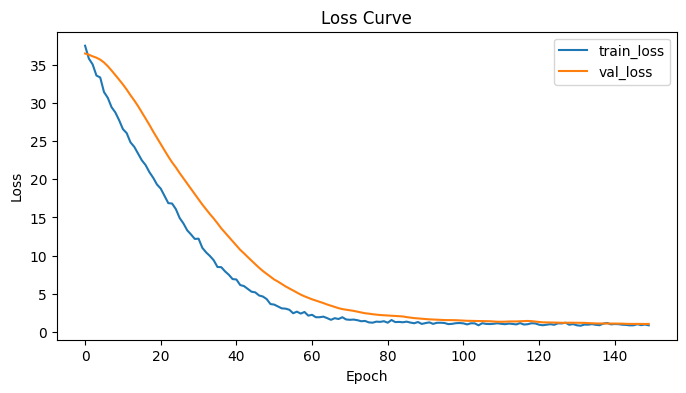

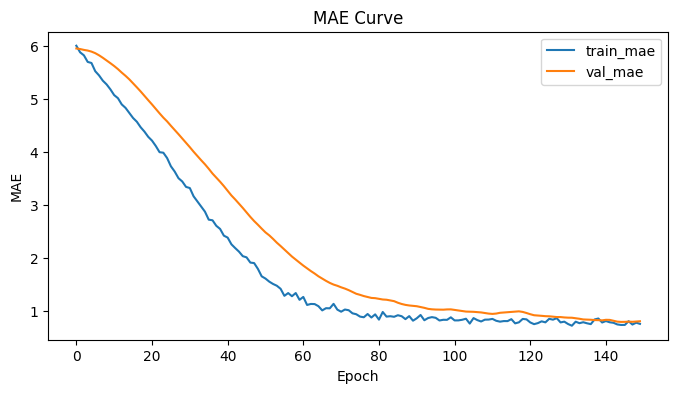

In [18]:
# ---- Train: Regression ----
reg = build_mlp(X_train_reg_s.shape[1], mode='regression')
reg.summary()

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

hist_reg = reg.fit(
    X_train_reg_s, y_train_reg,
    validation_split=VAL_SPLIT,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1,
    callbacks=[early_stop]
)

plot_history(hist_reg)

In [19]:
# ---- Evaluate: Regression ----
y_pred_reg = reg.predict(X_test_reg_s).ravel()
mae = mean_absolute_error(y_test_reg, y_pred_reg)
mse = mean_squared_error(y_test_reg, y_pred_reg)
r2 = r2_score(y_test_reg, y_pred_reg)
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"R^2: {r2:.4f}")


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
MAE: 0.7475
MSE: 0.9688
R^2: -0.0148


In [20]:

# ---- Save Models (optional) ----
ts = pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")
os.makedirs("models", exist_ok=True)
clf_path = f"models/{ts}_clf.keras"
reg_path = f"models/{ts}_reg.keras"
clf.save(clf_path)
reg.save(reg_path)
print("Saved:", clf_path, "and", reg_path)


Saved: models/20251226_162045_clf.keras and models/20251226_162045_reg.keras



## Notes & Tips

- Tweak `H1`, `H2`, `DROPOUT`, `L2`, `BATCH_SIZE`, `EPOCHS`, and `LEARNING_RATE` in the **Hyperparameters** cell.
- To try **L1** or **L1_L2** regularization, replace `regularizers.l2(...)` with `regularizers.l1(...)` or `regularizers.l1_l2(l1=..., l2=...)` in `build_mlp`.
- If your validation loss diverges from training loss, increase regularization or dropout, or reduce capacity.
- For imbalanced classes (few `good` wines), consider class weights or resampling.
- For reproducibility across machines, also pin library versions in a `requirements.txt`.


In [21]:
# ---- Define Multiple Labels ----
# Create a new column 'label' based on characteristics
conditions = (
    (df['alcohol'] > 10) &
    (df['density'] < 0.995) &
    (df['sulphates'] > 0.6) &
    (df['fixed acidity'] > 7) &
    (df['volatile acidity'] < 0.4)
)
df['label'] = conditions.astype(int)  # 1 for good, 0 for not good

# Check distribution of labels
print(df['label'].value_counts())

# ---- Check for Null Values ----
# Ensure no null values in selected features
selected_features = ['alcohol', 'density', 'sulphates', 'fixed acidity', 'volatile acidity']
null_counts = df[selected_features].isnull().sum()
print("Null values in selected features:")
print(null_counts)

# Handle null values if any (example: drop rows with nulls)
if null_counts.sum() > 0:
    df = df.dropna(subset=selected_features)
    print("Dropped rows with null values.")

label
0    407
1     27
Name: count, dtype: int64
Null values in selected features:
alcohol             0
density             0
sulphates           0
fixed acidity       0
volatile acidity    0
dtype: int64


MAE — Mean Absolute Error (1.54)
The model is off by 1.5 quality points on average.
Example:
If true quality = 7, prediction may be between 5.5 and 8.5.
Given wine quality ranges from 0–10, this is mediocre but not terrible.

MSE — Mean Squared Error (2.98)
Squared error punishes big mistakes more harshly.
Interpretation:
The model sometimes makes larger errors (2, 3, 4 points off).

R² = –3.56
This is the most important indicator.
What does negative R² mean?
R² = 0 → model is no better than predicting the mean
R² = 1 → perfect
R² < 0 → model is worse than predicting the average wine quality every time
This tells you:
Regression is performing poorly.
(It’s common with wine-quality dataset, because quality is very noisy and hard to predict.)

De facut o normalizare pe toate coloane
0.215 --> 1 
sau 
0.210 --> 0